In [286]:
import numpy as np
import polars as pl
import seaborn as sns

In [287]:
infpath = '/mnt/data/Max/repos/reverlor/param_selection/test_repeat_detection/data/find_repeats_results/merged.tsv'

In [288]:
df = pl.read_csv(infpath, separator='\t')

In [289]:
df = df.with_columns(
    (
        pl.col('repeat_len').cast(pl.String) \
        + '_' \
        + pl.col('repeat_idx').cast(pl.String) \
        + '_' \
        + pl.col('rate').cast(pl.String) \
    ).alias('repeat_id')
)

In [290]:
df.head()

repeat_len,repeat_idx,rate,value_type,start_coord,end_coord,repeat_id
i64,i64,f64,str,i64,i64,str
127,0,0.0,"""true""",197636,197763,"""127_0_0.0"""
127,0,0.0,"""true""",395498,395625,"""127_0_0.0"""
127,0,0.0,"""pred""",197636,197763,"""127_0_0.0"""
127,0,0.0,"""pred""",395498,395625,"""127_0_0.0"""
127,0,0.01,"""true""",197636,197763,"""127_0_0.01"""


In [291]:
true_df = df.filter(
    pl.col('value_type') == 'true'
)
pred_df = df.filter(
    pl.col('value_type') == 'pred'
)

In [292]:
true_df.shape

(400, 7)

In [293]:
pred_df.shape

(368, 7)

In [294]:
true_df.filter(pl.col('rate') == 0.0).head()

repeat_len,repeat_idx,rate,value_type,start_coord,end_coord,repeat_id
i64,i64,f64,str,i64,i64,str
127,0,0.0,"""true""",197636,197763,"""127_0_0.0"""
127,0,0.0,"""true""",395498,395625,"""127_0_0.0"""
127,1,0.0,"""true""",112221,112348,"""127_1_0.0"""
127,1,0.0,"""true""",515355,515482,"""127_1_0.0"""
127,10,0.0,"""true""",217278,217405,"""127_10_0.0"""


In [295]:
all_repeat_ids = frozenset(
    true_df['repeat_id']
)

In [296]:
MAX_ERROR_BP = 10

In [297]:
repeat_id_list = list()
repeat_start_coord_list = list()
repeat_found_list = list()

for repeat_id in all_repeat_ids:
    curr_true_df = true_df.filter(pl.col('repeat_id') == repeat_id)
    curr_pred_df = pred_df.filter(pl.col('repeat_id') == repeat_id)

    for true_row in curr_true_df.to_dicts():
        curr_pred_detect_df = curr_pred_df.filter(
            (pl.col('repeat_id') == repeat_id) \
          & ( (pl.col('start_coord') - true_row['start_coord']).abs() <= MAX_ERROR_BP ) \
          & ( (pl.col('end_coord')   - true_row['end_coord']).abs() <= MAX_ERROR_BP )
        )

        found_value = 0
        if curr_pred_detect_df.shape[0] > 0:
            found_value = 1
        # end if

        repeat_id_list.append(repeat_id)
        repeat_start_coord_list.append(true_row['start_coord'])
        repeat_found_list.append(found_value)
    # end for
# end for

In [298]:
print(len(repeat_id_list))
print(len(repeat_start_coord_list))
print(len(repeat_found_list))

repeat_detect_df = pl.DataFrame({
    'repeat_id': repeat_id_list,
    'repeat_start_coord': repeat_start_coord_list,
    'repeat_detected': repeat_found_list,
})

400
400
400


In [299]:
repeat_detect_df.shape

(400, 3)

In [300]:
assert repeat_detect_df.shape[0] == true_df.shape[0]

In [301]:
repeat_detect_df = repeat_detect_df.join(
    true_df,
    on='repeat_id',
    how='inner'
).select(
    pl.col('repeat_id', 'repeat_start_coord', 'repeat_detected', 'repeat_len', 'repeat_idx', 'rate')
).unique()

In [302]:
repeat_detect_df.shape

(400, 6)

In [303]:
repeat_detect_df.head()

repeat_id,repeat_start_coord,repeat_detected,repeat_len,repeat_idx,rate
str,i64,i64,i64,i64,f64
"""127_16_0.01""",337580,1,127,16,0.01
"""127_91_0.0""",388546,1,127,91,0.0
"""127_43_0.01""",92438,1,127,43,0.01
"""127_36_0.0""",278084,1,127,36,0.0
"""127_95_0.0""",263522,1,127,95,0.0


In [304]:
repeat_detect_df.filter(
    (pl.col('rate') == 0.0) & (pl.col('repeat_len') == 1000)
).sort(by='repeat_idx')

repeat_id,repeat_start_coord,repeat_detected,repeat_len,repeat_idx,rate
str,i64,i64,i64,i64,f64


In [305]:
repeat_detect_df.filter(
    (pl.col('rate') == 0.01) & (pl.col('repeat_len') == 200) & (pl.col('repeat_detected') != 1)
).sort(by='repeat_idx')

repeat_id,repeat_start_coord,repeat_detected,repeat_len,repeat_idx,rate
str,i64,i64,i64,i64,f64


In [306]:
df.filter(
    (pl.col('rate') == 0.01) & (pl.col('repeat_len') == 200) & (pl.col('repeat_idx') == 2)
).sort(by=['repeat_idx', 'value_type', 'start_coord'])

repeat_len,repeat_idx,rate,value_type,start_coord,end_coord,repeat_id
i64,i64,f64,str,i64,i64,str


In [307]:
N_repeats = true_df.filter(
    pl.col('rate') == 0.0
).shape[0]
print('N_repeats = {}'.format(N_repeats))

per_rate_summary_df = repeat_detect_df.group_by('rate').agg(
    pl.col('repeat_detected').sum().alias('repeat_detected_count')
).sort(by=['rate'])

per_rate_summary_df = per_rate_summary_df.with_columns(
    (pl.col('repeat_detected_count') / N_repeats * 100.0).alias('repeat_detected_percent')
)

per_rate_summary_df.head(10)

N_repeats = 200


rate,repeat_detected_count,repeat_detected_percent
f64,i64,f64
0.0,200,100.0
0.01,168,84.0


In [308]:
def get_per_rate_df(repeat_detect_df, true_df, repeat_len=200):
    N_repeats = true_df.filter(
        (pl.col('repeat_len') == repeat_len) \
        & (pl.col('rate') == 0.0)
    ).shape[0]
    print('N_repeats = {}'.format(N_repeats))
    
    result_df = repeat_detect_df.filter(
        pl.col('repeat_len') == repeat_len
    ).group_by('rate').agg(
        pl.col('repeat_detected').sum().alias('repeat_detected_count')
    ).sort(by=['rate'])
    
    result_df = result_df.with_columns(
        (pl.col('repeat_detected_count') / N_repeats * 100.0).alias('repeat_detected_percent')
    )

    return result_df
# end def

In [309]:
per_rate_len127_summary_df = get_per_rate_df(
    repeat_detect_df,
    true_df,
    repeat_len=127
)
per_rate_len127_summary_df.head(10)

N_repeats = 200


rate,repeat_detected_count,repeat_detected_percent
f64,i64,f64
0.0,200,100.0
0.01,168,84.0


In [310]:
per_rate_len200_summary_df = get_per_rate_df(
    repeat_detect_df,
    true_df,
    repeat_len=200
)
per_rate_len200_summary_df.head(10)

N_repeats = 0


rate,repeat_detected_count,repeat_detected_percent
f64,i64,f64


In [311]:
per_rate_len500_summary_df = get_per_rate_df(
    repeat_detect_df,
    true_df,
    repeat_len=500
)
per_rate_len500_summary_df.head(10)

N_repeats = 0


rate,repeat_detected_count,repeat_detected_percent
f64,i64,f64


In [312]:
per_rate_len1k_summary_df = get_per_rate_df(
    repeat_detect_df,
    true_df,
    repeat_len=1000
)
per_rate_len1k_summary_df.head(10)

N_repeats = 0


rate,repeat_detected_count,repeat_detected_percent
f64,i64,f64


In [313]:
per_rate_len10k_summary_df = get_per_rate_df(
    repeat_detect_df,
    true_df,
    repeat_len=10000
)
per_rate_len10k_summary_df.head(10)

N_repeats = 0


rate,repeat_detected_count,repeat_detected_percent
f64,i64,f64


<Axes: xlabel='rate', ylabel='repeat_detected_percent'>

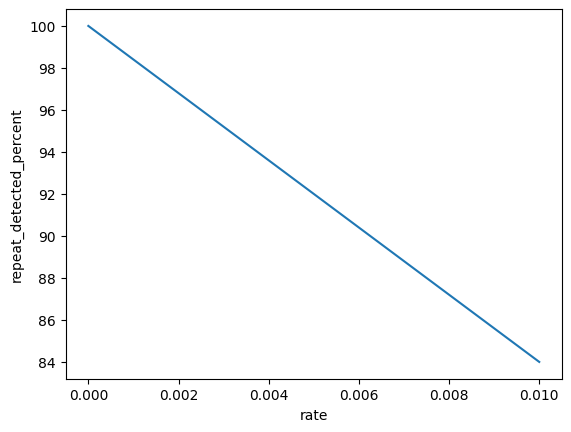

In [314]:
sns.lineplot(
    per_rate_summary_df,
    x='rate',
    y='repeat_detected_percent'
)

<Axes: xlabel='rate', ylabel='repeat_detected_percent'>

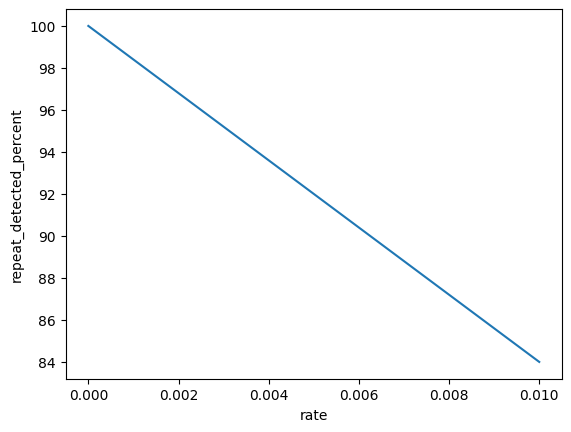

In [315]:
sns.lineplot(
    per_rate_len127_summary_df,
    x='rate',
    y='repeat_detected_percent'
)

<Axes: xlabel='rate', ylabel='repeat_detected_percent'>

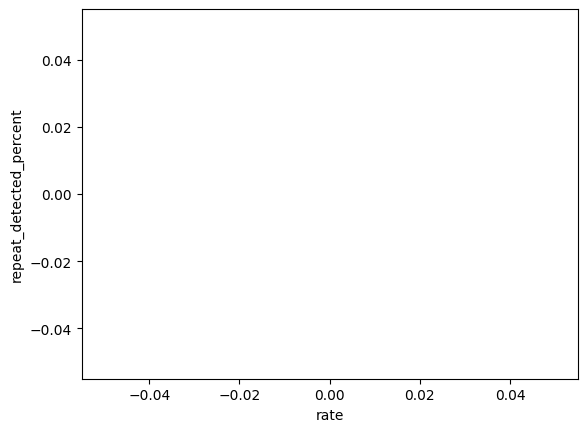

In [316]:
sns.lineplot(
    per_rate_len200_summary_df,
    x='rate',
    y='repeat_detected_percent'
)

<Axes: xlabel='rate', ylabel='repeat_detected_percent'>

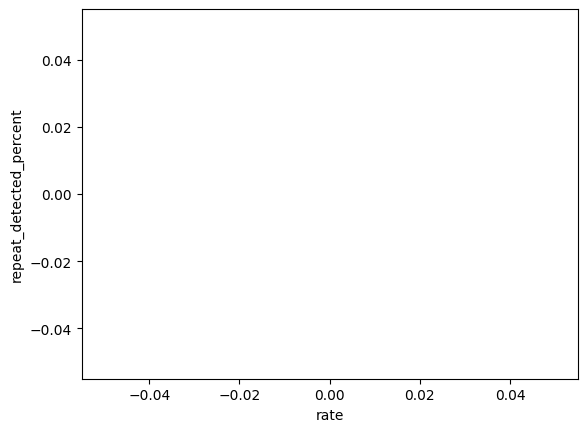

In [317]:
sns.lineplot(
    per_rate_len500_summary_df,
    x='rate',
    y='repeat_detected_percent'
)

<Axes: xlabel='rate', ylabel='repeat_detected_percent'>

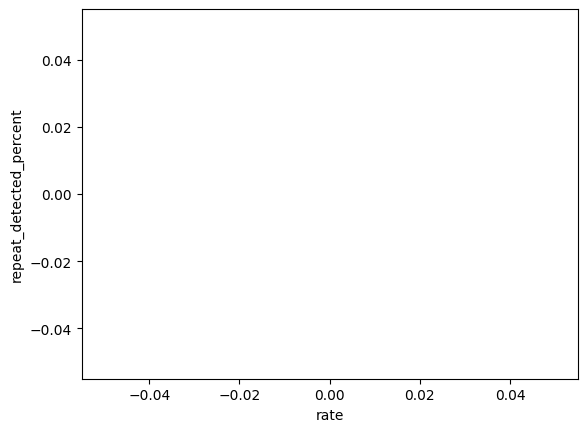

In [318]:
sns.lineplot(
    per_rate_len1k_summary_df,
    x='rate',
    y='repeat_detected_percent'
)

<Axes: xlabel='rate', ylabel='repeat_detected_percent'>

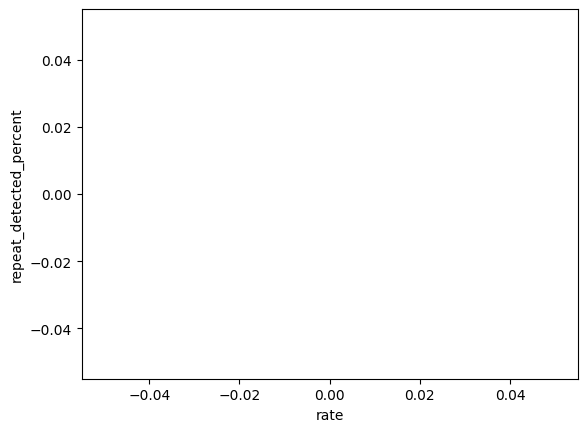

In [319]:
sns.lineplot(
    per_rate_len10k_summary_df,
    x='rate',
    y='repeat_detected_percent'
)